# Single-Cell RNA-Sequencing Gene Expression Project

### Load Data

In [1]:
import os
import random

os.environ.setdefault("MPLCONFIGDIR", ".matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", ".cache")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import poisson

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

SEED = 100

sns.set_theme(style="whitegrid", context="notebook")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()
zeisel = pd.read_csv('Zeisel.csv')
print(zeisel)

          Unnamed: 0          cell_type  Sema3c  Atp1b2  Prkar2b  Cxcl14  \
0     1772071015_C02       interneurons      11       9        5      22   
1     1772071017_G12       interneurons       0       5        1      18   
2     1772071017_A05       interneurons      25       8       14      26   
3     1772071014_B06       interneurons       1       6        5      93   
4     1772067065_H06       interneurons      10       7       21       0   
...              ...                ...     ...     ...      ...     ...   
3000  1772067059_B04  endothelial-mural       0       1        0       0   
3001  1772066097_D04  endothelial-mural       0       0        0       0   
3002  1772063068_D01  endothelial-mural       0       0        0       0   
3003  1772066098_A12  endothelial-mural       0       1        0       1   
3004  1772058148_F03  endothelial-mural       0       2        0       0   

      Rit2  Scg2  L2hgdh  Cited2  ...  Irak1  Lage3  G6pdx  Fundc2  Zmat1  \
0        2

## Preliminary Exploratory Data Analysis

In [2]:
counts = zeisel.iloc[:, 2:].to_numpy()
hidden_labels = zeisel.iloc[:, 1]
gene_names = zeisel.columns[2:]
print("counts shape:", counts.shape)
print("unique cell types:", pd.unique(hidden_labels).tolist())
print("fraction of zeros:", round((counts == 0).mean(), 3))

counts shape: (3005, 1000)
unique cell types: ['interneurons', 'pyramidal SS', 'pyramidal CA1', 'oligodendrocytes', 'microglia', 'endothelial-mural', 'astrocytes_ependymal']
fraction of zeros: 0.774


,quantity,value
0,cells,3005
1,genes,1000
2,median library size,729
3,median zero fraction,78.4%


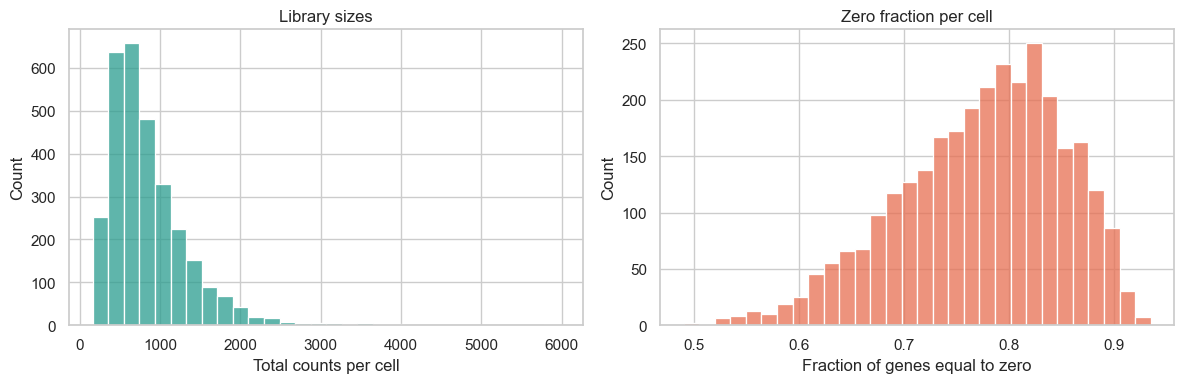

In [3]:
library_size = counts.sum(axis=1, keepdims=True)
cpm = counts / np.clip(library_size, 1, None) * 1.0e4
log_cpm = np.log1p(cpm).astype(np.float32)

summary = pd.DataFrame(
    {
        "quantity": [
            "cells",
            "genes",
            "median library size",
            "median zero fraction",
        ],
        "value": [
            counts.shape[0],
            counts.shape[1],
            int(np.median(library_size)),
            f"{np.median((counts == 0).mean(axis=1)):.1%}",
        ],
    }
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(library_size.ravel(), bins=30, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Library sizes")
axes[0].set_xlabel("Total counts per cell")

sns.histplot((counts == 0).mean(axis=1), bins=30, ax=axes[1], color="#E76F51")
axes[1].set_title("Zero fraction per cell")
axes[1].set_xlabel("Fraction of genes equal to zero")

plt.tight_layout()
plt.show()


## Dimension Reduction

### Top Ten Most-Variable Genes

In [4]:
def top_variable_genes(log_cpm, top_n):
    return np.argsort(log_cpm.var(axis=0))[-top_n:]


top_idx = top_variable_genes(log_cpm, top_n=80)
scaler = StandardScaler()
x = scaler.fit_transform(log_cpm[:, top_idx]).astype(np.float32)

print("input to PCA/VAE:", x.shape)
print("first 10 selected genes:", [gene_names[i] for i in top_idx[:10]])

input to PCA/VAE: (3005, 80)
first 10 selected genes: ['Ryr3', 'Acot13', 'Ddr1', 'Ube2b', 'Agrn', 'Nudt4', 'Evi2a.evi2b', 'Mfge8', 'Cacna1a', 'Sat1']


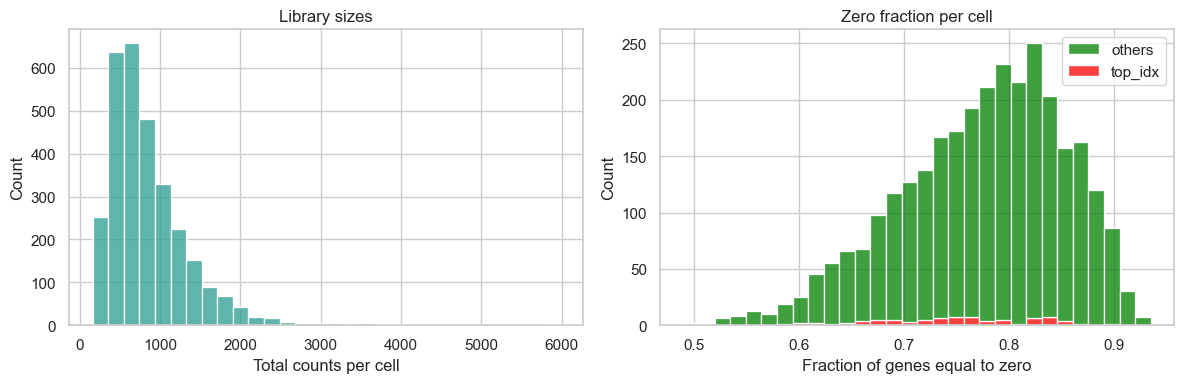

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(library_size.ravel(), bins=30, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Library sizes")
axes[0].set_xlabel("Total counts per cell")

vals = (counts == 0).mean(axis=1)
mask = np.ones(len(vals), dtype=bool)
mask[top_idx] = False
# combine data
vals_combined = np.concatenate([vals[top_idx], vals[mask]])
labels = (["top_idx"] * len(vals[top_idx])) + (["others"] * len(vals[mask]))

sns.histplot(
    x=vals_combined,
    hue=labels,
    bins=30,
    multiple="stack",
    hue_order=["others", "top_idx"],
    palette={"top_idx": "red", "others": "green"},
    ax=axes[1]
)

axes[1].set_title("Zero fraction per cell")
axes[1].set_xlabel("Fraction of genes equal to zero")

plt.tight_layout()
plt.show()

### Principal Component Analysis

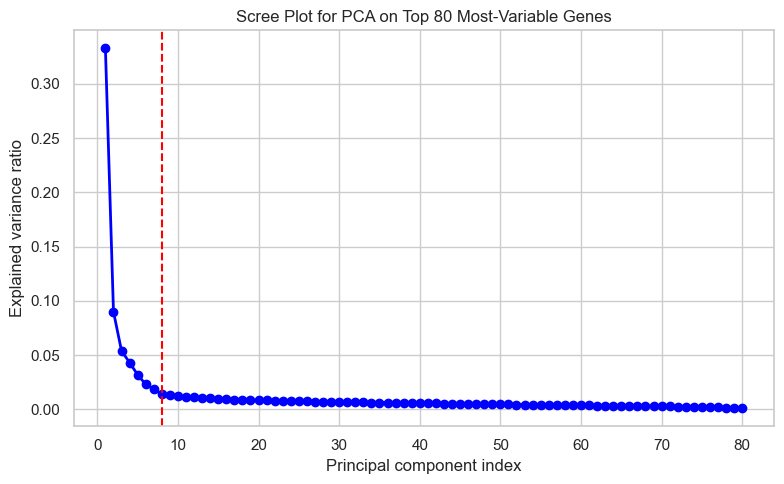

In [6]:
pca = PCA()
pca.fit(x)
exp_var_pca = pca.explained_variance_ratio_
PC_values = np.arange(pca.n_components_) + 1

# 3. Create the Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.axvline(8, color='red', linestyle='--')
plt.title("Scree Plot for PCA on Top 80 Most-Variable Genes")
plt.tight_layout()
plt.show()

## K-Means

PCA + KMeans: ARI = 0.796, NMI = 0.748


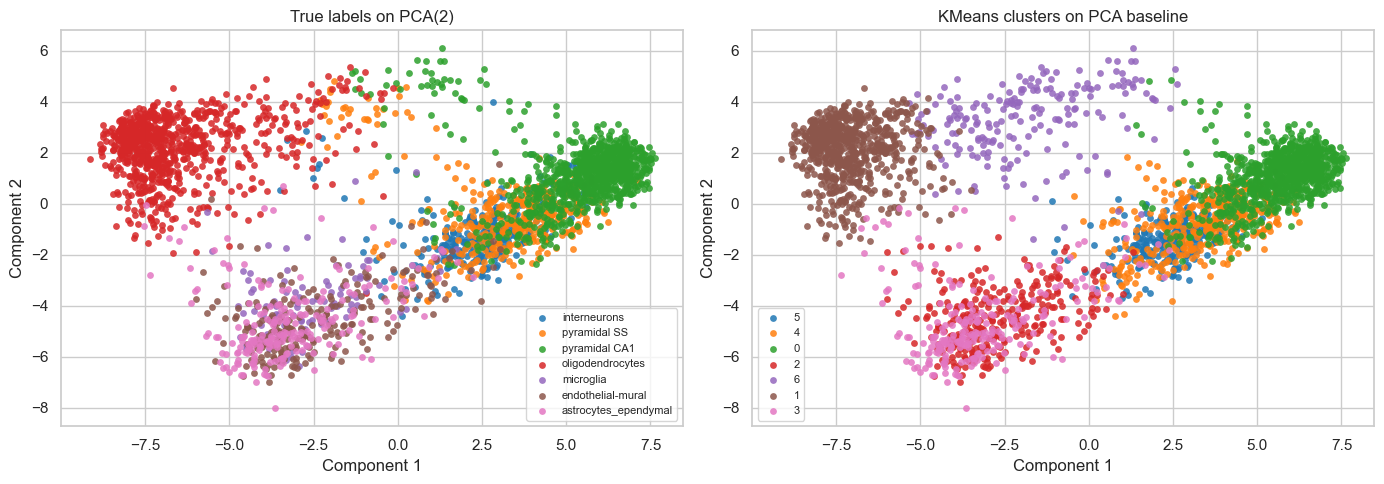

In [7]:
def plot_embedding(ax, coords, labels, title):
    labels = np.asarray(labels)
    order = pd.unique(labels)
    palette = sns.color_palette("tab10", n_colors=len(order))
    for label, color in zip(order, palette):
        mask = labels == label
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=24,
            alpha=0.85,
            color=[color],
            label=str(label),
            linewidths=0,
        )
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(loc="best", fontsize=8, frameon=True)


pca8 = PCA(n_components=5, random_state=SEED).fit_transform(x)
pca_kmeans = KMeans(n_clusters=7, n_init=50, random_state=SEED).fit_predict(pca8)

pca_ari = adjusted_rand_score(hidden_labels, pca_kmeans)
pca_nmi = normalized_mutual_info_score(hidden_labels, pca_kmeans)

print(f"PCA + KMeans: ARI = {pca_ari:.3f}, NMI = {pca_nmi:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_embedding(axes[0], pca8, hidden_labels, "True labels on PCA(2)")
plot_embedding(axes[1], pca8, pca_kmeans, "KMeans clusters on PCA baseline")
plt.tight_layout()
plt.show()

### Naive K-Means

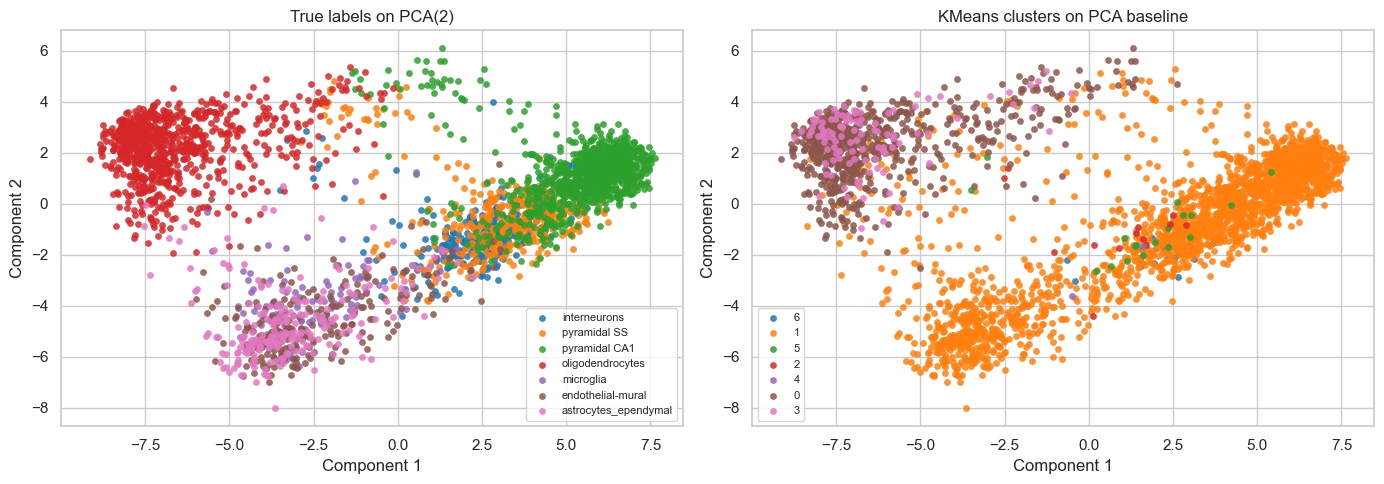

In [8]:
kmeans = KMeans(n_clusters=7, n_init=50, random_state=SEED).fit_predict(counts)
kmeans_ari = adjusted_rand_score(hidden_labels, kmeans)
kmeans_nmi = normalized_mutual_info_score(hidden_labels, kmeans)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_embedding(axes[0], pca8, hidden_labels, "True labels on PCA(2)")
plot_embedding(axes[1], pca8, kmeans, "KMeans clusters on PCA baseline")
plt.tight_layout()
plt.show()

## Poisson Mixture Models

In [9]:
pois_x = counts[:, top_idx]
pois_x.shape

(3005, 80)

In [10]:
def multivariate_poisson_mixture_em(X, K, max_iter=100, tol=1e-6):
    N, D = X.shape
    
    pi = np.full(K, 1/K)
    lambdas = np.random.uniform(0.5, 1.5, (K, D)) * np.mean(X, axis=0)
    
    for i in range(max_iter):
        log_probs = np.zeros((N, K))
        for k in range(K):
            log_probs[:, k] = np.sum(poisson.logpmf(X, lambdas[k, :]), axis=1) + np.log(pi[k])
            
        log_max = np.max(log_probs, axis=1, keepdims=True)
        resp = np.exp(log_probs - log_max)
        resp /= np.sum(resp, axis=1, keepdims=True)
        
        Nk = np.sum(resp, axis=0)
        pi_new = Nk / N
        lambdas_new = (resp.T @ X) / Nk[:, np.newaxis]
        
        if np.allclose(lambdas, lambdas_new, atol=tol):
            break
            
        pi, lambdas = pi_new, lambdas_new
        
    return pi, lambdas, resp

In [11]:
fitted_lambdas, fitted_pi, responsibilities = multivariate_poisson_mixture_em(pois_x, K=7, max_iter=100, tol=1e-6)
clusters = np.argmax(responsibilities, axis=1)

In [12]:
pmm_ari = adjusted_rand_score(hidden_labels, clusters)
pmm_nmi = normalized_mutual_info_score(hidden_labels, clusters)
print(f"GMM: ARI = {pmm_ari:.3f}, NMI = {pmm_nmi:.3f}")

GMM: ARI = 0.367, NMI = 0.495


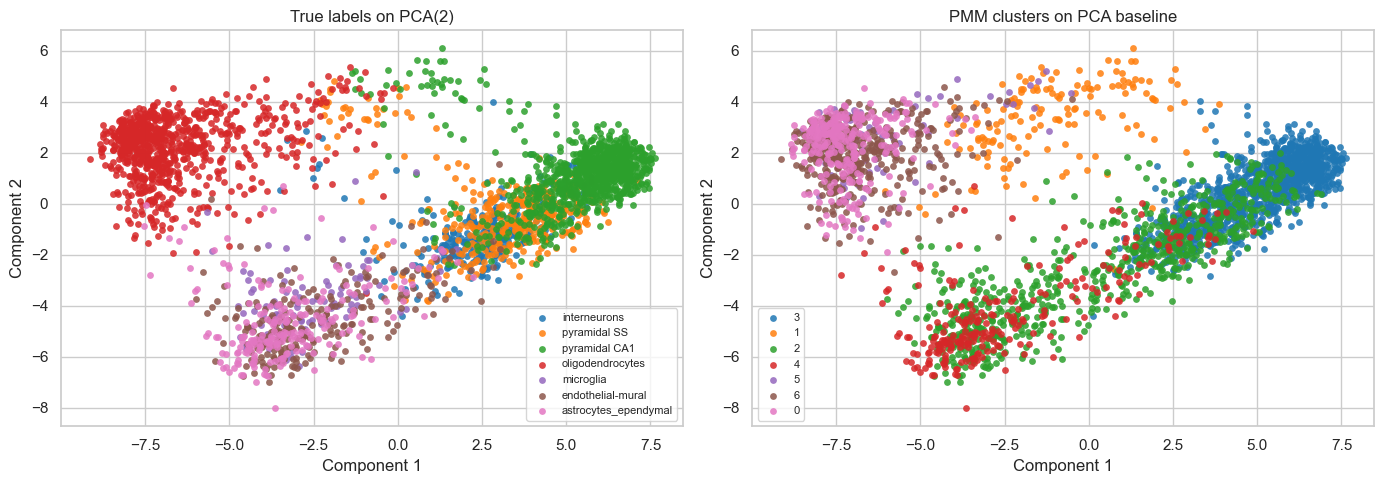

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_embedding(axes[0], pca8, hidden_labels, "True labels on PCA(2)")
plot_embedding(axes[1], pca8, clusters, "PMM clusters on PCA baseline")
plt.tight_layout()
plt.show()

## Variational Autoencoders

In [14]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim, activation, hidden_dims=[64], latent_dim=2):
        super().__init__()

        # ---- Encoder ----
        encoder_layers = []
        prev_dim = input_dim

        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(activation())
            prev_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)

        # Latent space
        self.mu = nn.Linear(prev_dim, latent_dim)
        self.logvar = nn.Linear(prev_dim, latent_dim)

        # ---- Decoder ----
        decoder_layers = []
        prev_dim = latent_dim

        for h_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(activation())
            prev_dim = h_dim

        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [15]:
def train_vae(x, activation, hidden_dims=[64], latent_dim=2,
              beta=0.01, epochs=80, batch_size=64):

    set_seed()
    x_tensor = torch.tensor(x, dtype=torch.float32)
    loader = DataLoader(TensorDataset(x_tensor),
                        batch_size=batch_size, shuffle=True)

    model = VariationalAutoencoder(
        input_dim=x_tensor.shape[1],
        activation=activation,
        hidden_dims=hidden_dims,
        latent_dim=latent_dim,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = []

    for epoch in range(1, epochs + 1):
        losses, recon_losses, kl_losses = [], [], []

        for (batch,) in loader:
            optimizer.zero_grad()

            recon, mu, logvar = model(batch)

            recon_loss = F.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.mean(
                1 + logvar - mu.pow(2) - logvar.exp()
            )

            loss = recon_loss + beta * kl_loss
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            recon_losses.append(recon_loss.item())
            kl_losses.append(kl_loss.item())

        history.append({
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "recon_loss": float(np.mean(recon_losses)),
            "kl_loss": float(np.mean(kl_losses)),
        })

    with torch.no_grad():
        latent_mean, _ = model.encode(x_tensor)

    return model, latent_mean.numpy(), pd.DataFrame(history)

In [16]:
def plot_marker_landscapes(model, latent_mean, scaler, selected_gene_idx, marker_blocks, names):
    with torch.no_grad():
        z = latent_mean
        grid_x = np.linspace(z[:, 0].min() - 0.5, z[:, 0].max() + 0.5, 25)
        grid_y = np.linspace(z[:, 1].min() - 0.5, z[:, 1].max() + 0.5, 25)
        xx, yy = np.meshgrid(grid_x, grid_y)
        latent_grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

        decoded_std = model.decoder(torch.tensor(latent_grid)).numpy()
        decoded_log_cpm = scaler.inverse_transform(decoded_std)

    # Create a 2x4 grid (we'll only use 7 plots)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, (name, block) in enumerate(zip(names, marker_blocks)):
        ax = axes[i]
        mask = np.isin(selected_gene_idx, block)
        score = decoded_log_cpm[:, mask].mean(axis=1).reshape(xx.shape)

        sns.heatmap(score, cmap="viridis", ax=ax, cbar=True)
        ax.set_title(f"{name} marker program")
        ax.set_xlabel("latent z1")
        ax.set_ylabel("latent z2")

    # Remove the unused 8th subplot (bottom-right corner)
    for j in range(len(names), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

n_types = len(pd.unique(hidden_labels))
n_genes = len(pd.unique(gene_names))
marker_blocks = np.array_split(np.arange(n_genes), n_types)

In [17]:
def run_model_and_plot(x, activation = nn.ReLU, hidden_dims=[64], latent_dim=2, beta=0.01, epochs=80):
    # Train the VAE on x with specified hyperparameters and unpack the three return values
    vae, latent_mean, history = train_vae(x, activation = activation, hidden_dims=hidden_dims, 
                                          latent_dim=latent_dim, beta=beta, epochs=epochs)
    # Cluster the 2D latent means into 4 clusters using KMeans with 50 random initialisations for stability
    vae_kmeans = KMeans(n_clusters=7, n_init=50, random_state=SEED).fit_predict(latent_mean)

    vae_ari = adjusted_rand_score(hidden_labels, vae_kmeans)          # Compute ARI: measures cluster-to-true-label agreement (1.0 = perfect)
    vae_nmi = normalized_mutual_info_score(hidden_labels, vae_kmeans) # Compute NMI: measures shared information between clusters and true labels (1.0 = perfect)

    print(f"VAE + KMeans: ARI = {vae_ari:.3f}, NMI = {vae_nmi:.3f}") # Print both metrics rounded to 3 decimal places
    print(history.tail())  # Display the last 5 rows of training history to inspect convergence
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    axes[0].plot(history["epoch"], history["loss"], label="total loss", lw=2)
    axes[0].plot(history["epoch"], history["recon_loss"], label="reconstruction", lw=2)
    axes[0].plot(history["epoch"], history["kl_loss"], label="KL", lw=2)
    axes[0].set_title("VAE training curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    plot_embedding(axes[1], latent_mean, hidden_labels, "True labels in VAE latent space")
    plot_embedding(axes[2], latent_mean, vae_kmeans, "KMeans clusters in VAE latent space")

    plt.tight_layout()
    plt.show()

    # plot_marker_landscapes(
    #     model=vae,
    #     latent_mean=latent_mean,
    #     scaler=scaler,
    #     selected_gene_idx=top_idx,
    #     marker_blocks=marker_blocks,
    #     names=gene_names,
    # )
    return vae_ari, vae_nmi

### VAE: 1 Hidden Layer w/ ReLU

VAE + KMeans: ARI = 0.751, NMI = 0.725
    epoch      loss  recon_loss   kl_loss
75     76  0.507165    0.481051  2.611396
76     77  0.506165    0.480250  2.591516
77     78  0.506174    0.480296  2.587801
78     79  0.505883    0.480108  2.577522
79     80  0.505500    0.479778  2.572217


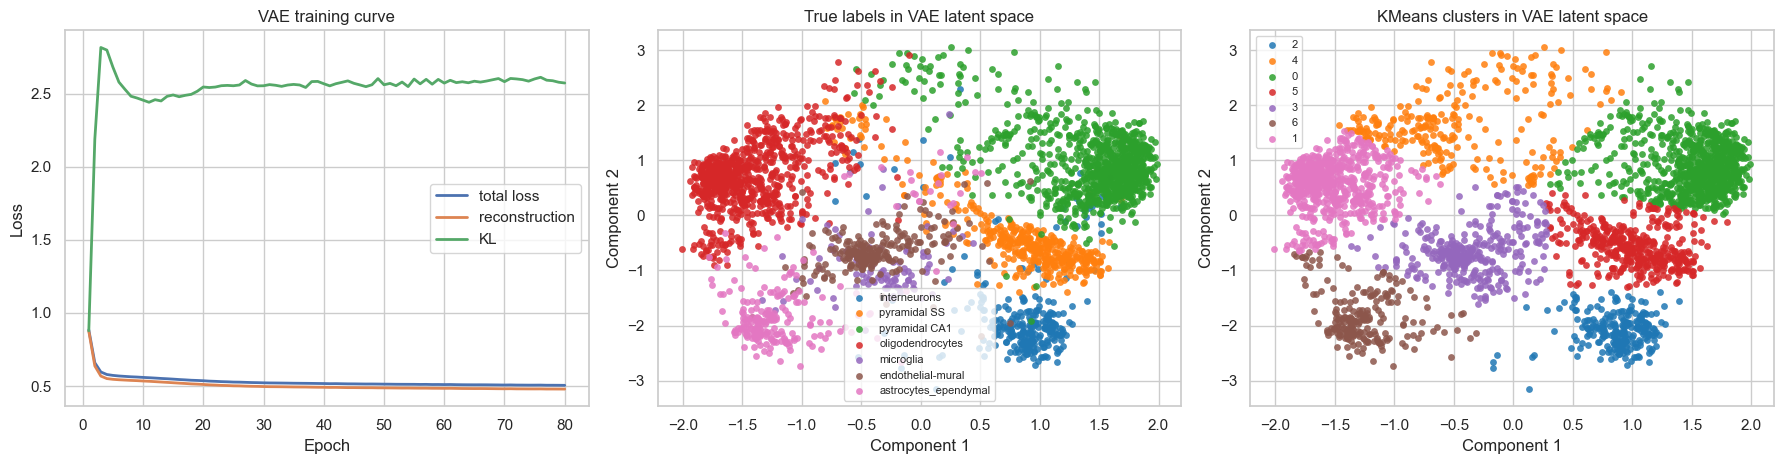

In [18]:
vae_relu_ari, vae_relu_nmi = run_model_and_plot(x, activation = nn.ReLU, hidden_dims=[64], latent_dim=2, beta=0.01, epochs=80)

VAE + KMeans: ARI = 0.441, NMI = 0.492
   epoch      loss  recon_loss   kl_loss
0      1  0.884888    0.876105  0.878295


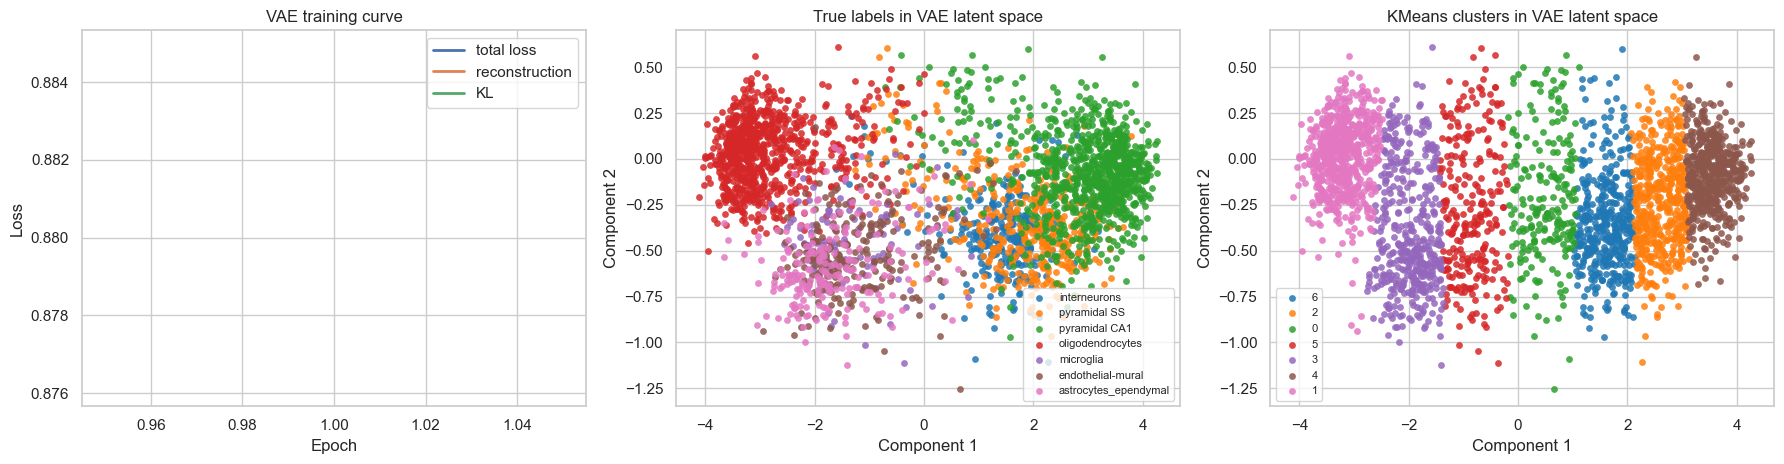

In [19]:
vae1_relu_ari, vae1_relu_nmi = run_model_and_plot(x, activation = nn.ReLU, hidden_dims=[64], latent_dim=2, beta=0.01, epochs=1-0)

VAE + KMeans: ARI = 0.715, NMI = 0.708
     epoch      loss  recon_loss   kl_loss
115    116  0.500102    0.474223  2.587913
116    117  0.499589    0.473298  2.629105
117    118  0.499283    0.473042  2.624141
118    119  0.499739    0.473536  2.620223
119    120  0.498980    0.472733  2.624686


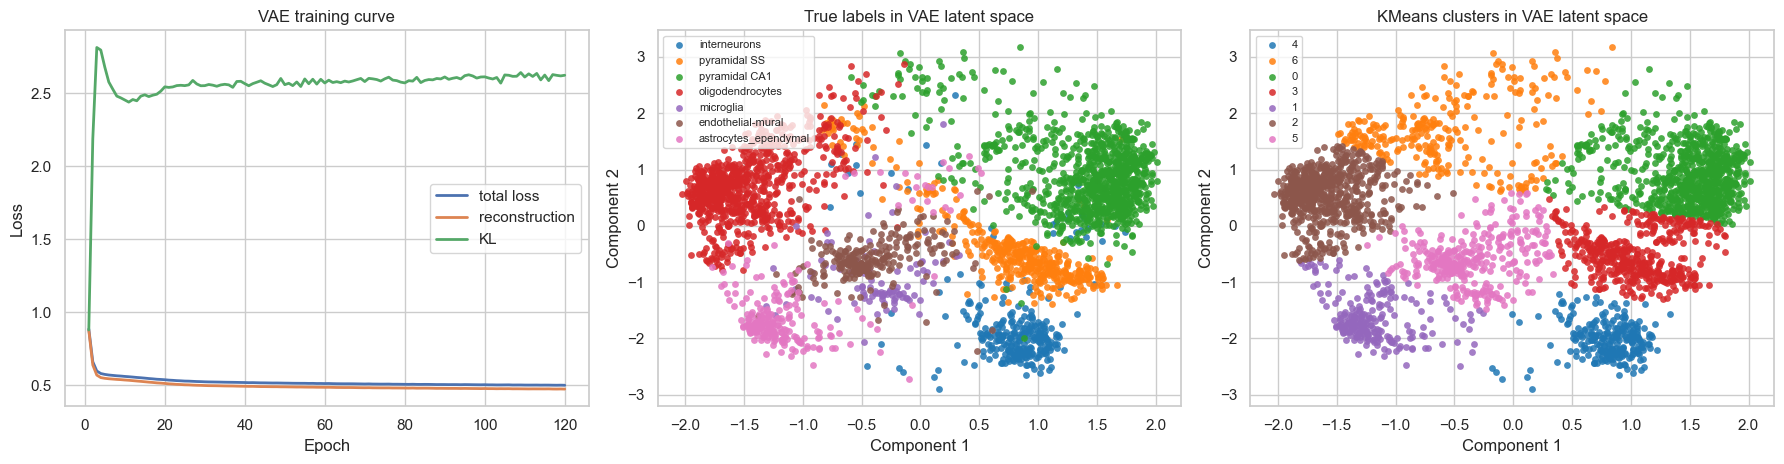

In [20]:
vae_relu_ari, vae_relu_nmi = run_model_and_plot(x, activation = nn.ReLU, hidden_dims=[64], latent_dim=2, beta=0.01, epochs=120)

### VAE: 1 Hidden Layer w/ Sigmoid

VAE + KMeans: ARI = 0.694, NMI = 0.667
    epoch      loss  recon_loss   kl_loss
75     76  0.540881    0.516330  2.455077
76     77  0.539994    0.515570  2.442402
77     78  0.539623    0.515167  2.445666
78     79  0.539154    0.514606  2.454788
79     80  0.538335    0.514080  2.425489


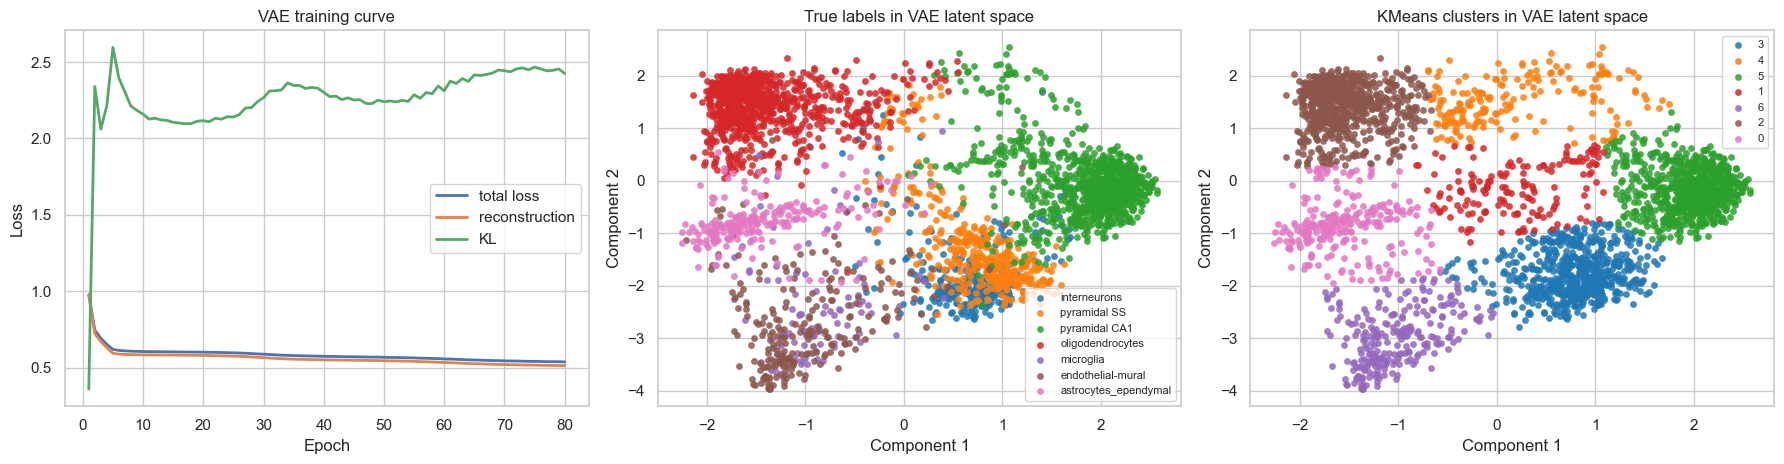

In [21]:
vae1_sig_ari, vae1_sig_nmi = run_model_and_plot(x, activation = nn.Sigmoid, hidden_dims=[64], latent_dim=2, beta=0.01, epochs=80)

### VAE: 2 Hidden Layers w/ ReLU

VAE + KMeans: ARI = 0.659, NMI = 0.667
    epoch      loss  recon_loss   kl_loss
75     76  0.481761    0.455868  2.589371
76     77  0.481082    0.454886  2.619615
77     78  0.480325    0.454377  2.594714
78     79  0.480821    0.454843  2.597851
79     80  0.480551    0.454530  2.602123


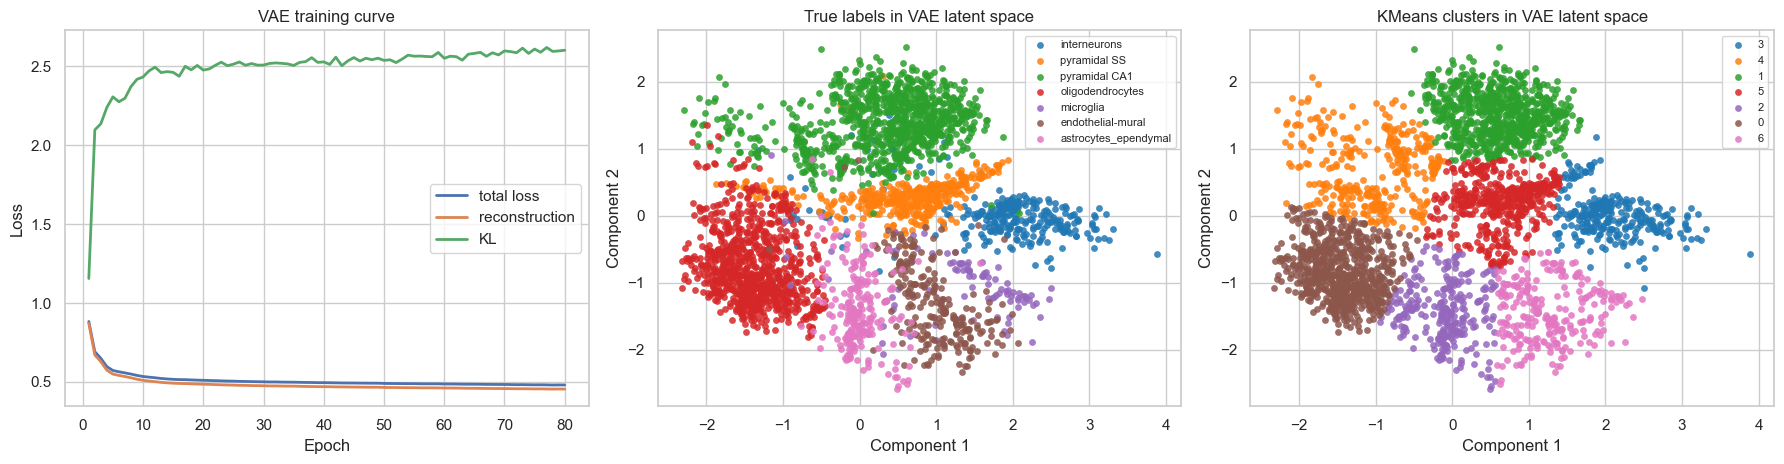

In [22]:
vae2_relu_ari, vae2_relu_nmi = run_model_and_plot(x, activation = nn.ReLU, hidden_dims=[64,64], latent_dim=2, beta=0.01, epochs=80)

### VAE: 2 Hidden Layer w/ Sigmoid

VAE + KMeans: ARI = 0.548, NMI = 0.618
    epoch      loss  recon_loss   kl_loss
75     76  0.498168    0.474432  2.373576
76     77  0.497801    0.473879  2.392213
77     78  0.496267    0.472734  2.353392
78     79  0.496755    0.473123  2.363151
79     80  0.495908    0.472092  2.381569


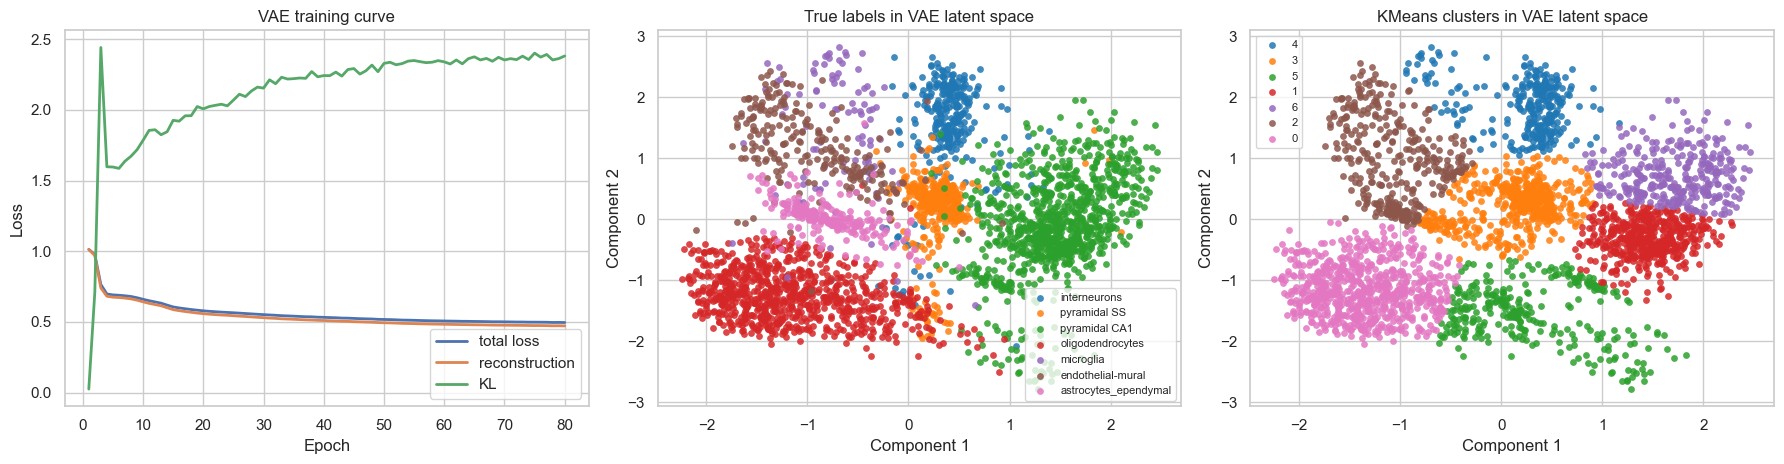

In [23]:
vae2_sig_ari, vae2_sig_nmi = run_model_and_plot(x, activation = nn.Sigmoid, hidden_dims=[64, 64], latent_dim=2, beta=0.01, epochs=80)

### VAE: 3 Hidden Layers w/ ReLU

VAE + KMeans: ARI = 0.569, NMI = 0.628
    epoch      loss  recon_loss   kl_loss
75     76  0.472541    0.446827  2.571359
76     77  0.471984    0.446151  2.583311
77     78  0.471572    0.445347  2.622423
78     79  0.471980    0.445965  2.601544
79     80  0.471866    0.445958  2.590745


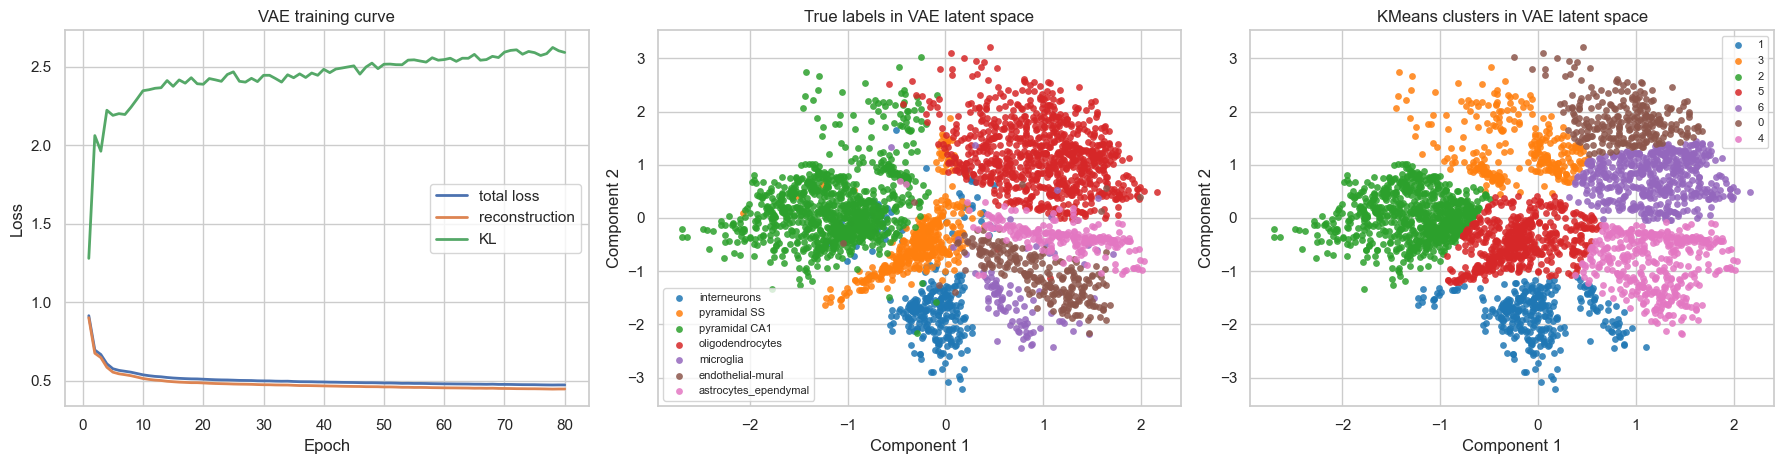

In [24]:
vae3_relu_ari, vae3_relu_nmi = run_model_and_plot(x, activation = nn.ReLU, hidden_dims=[64,64,64], latent_dim=2, beta=0.01, epochs=80)

### VAE: 3 Hidden Layer w/ Sigmoid

VAE + KMeans: ARI = 0.507, NMI = 0.642
    epoch      loss  recon_loss   kl_loss
75     76  0.557215    0.542838  1.437737
76     77  0.556189    0.541994  1.419488
77     78  0.556194    0.541914  1.427990
78     79  0.554891    0.540556  1.433506
79     80  0.554329    0.540036  1.429293


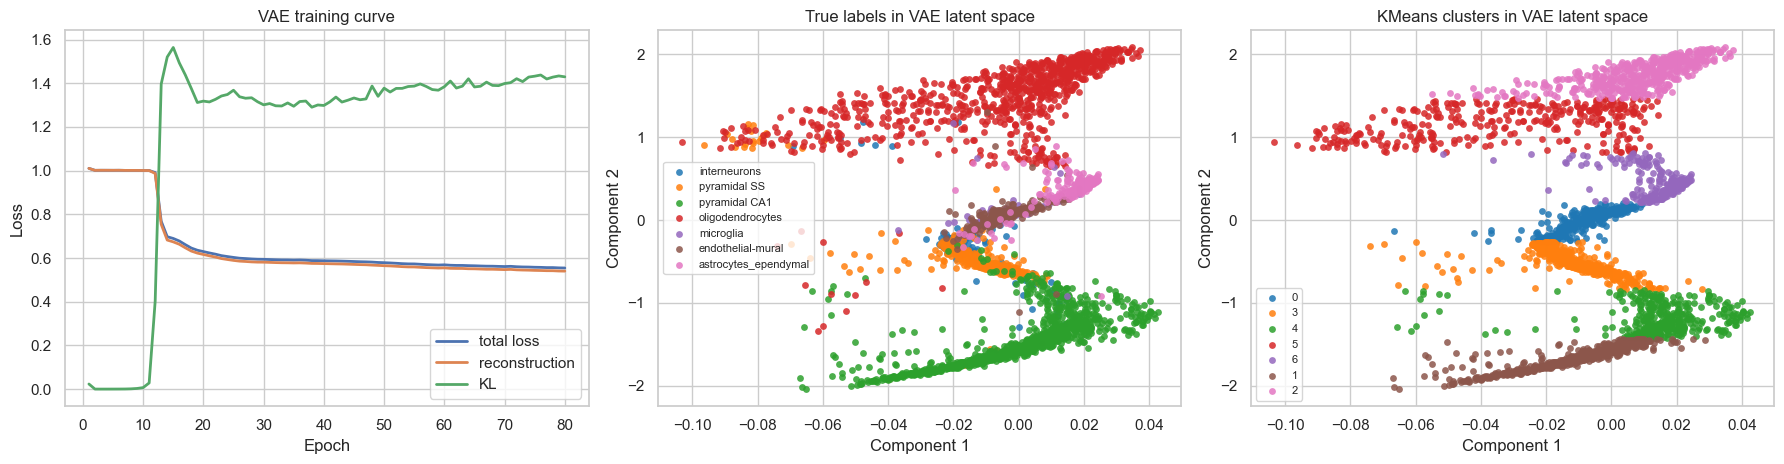

In [25]:
vae3_sig_ari, vae3_sig_nmi = run_model_and_plot(x, activation = nn.Sigmoid, hidden_dims=[64,64, 64], latent_dim=2, beta=0.01, epochs=80)

## Comparison

In [26]:
comparison = pd.DataFrame(
    [
        {
            "representation": "Naive KMeans",
            "ARI": kmeans_ari,
            "NMI": kmeans_nmi,
        },
        {
            "representation": "PCA(8) + KMeans",
            "ARI": pca_ari,
            "NMI": pca_nmi,
        },
        {
            "representation": "Poisson Gaussian Model",
            "ARI": pmm_ari,
            "NMI": pmm_nmi,
        },
        {
            "representation": "1-Hidden-Layer 2D VAE latent mean (ReLU) + KMeans",
            "ARI": vae1_relu_ari,
            "NMI": vae1_relu_nmi,
        },
        {
            "representation": "2-Hidden-Layer 2D VAE latent mean (ReLU) + KMeans",
            "ARI": vae2_relu_ari,
            "NMI": vae2_relu_nmi,
        },
        {
            "representation": "3-Hidden-Layer 2D VAE latent mean (ReLU) + KMeans",
            "ARI": vae3_relu_ari,
            "NMI": vae3_relu_nmi,
        },
        {
            "representation": "1-Hidden-Layer 2D VAE latent mean (Sigmoid) + KMeans",
            "ARI": vae1_sig_ari,
            "NMI": vae1_sig_nmi,
        },
        {
            "representation": "2-Hidden-Layer 2D VAE latent mean (Sigmoid) + KMeans",
            "ARI": vae2_sig_ari,
            "NMI": vae2_sig_nmi,
        },
        {
            "representation": "3-Hidden-Layer 2D VAE latent mean (Sigmoid) + KMeans",
            "ARI": vae3_sig_ari,
            "NMI": vae3_sig_nmi,
        },
    ]
).round(3)

comparison

,representation,ARI,NMI
0,Naive KMeans,0.196,0.353
1,PCA(8) + KMeans,0.796,0.748
2,Poisson Gaussian Model,0.367,0.495
3,1-Hidden-Layer 2D VAE latent mean (ReLU) + KMeans,0.441,0.492
4,2-Hidden-Layer 2D VAE latent mean (ReLU) + KMeans,0.659,0.667
5,3-Hidden-Layer 2D VAE latent mean (ReLU) + KMeans,0.569,0.628
6,1-Hidden-Layer 2D VAE latent mean (Sigmoid) + ...,0.694,0.667
7,2-Hidden-Layer 2D VAE latent mean (Sigmoid) + ...,0.548,0.618
8,3-Hidden-Layer 2D VAE latent mean (Sigmoid) + ...,0.507,0.642
